# Setup

In [152]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [153]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

from VirtualSAS_theory import VirtualSAS_theory

from AFL.double_agent import *
from AFL.double_agent.PyTorchExtrapolator import DirichletGPExtrapolator 

from tqdm.auto import tqdm 
from typing import Optional, Union, List, Tuple, Dict, Any

### Create Virtual Instrument

In [154]:
from AFL.automation.APIServer.data.DataTrashcan import DataTrashcan

boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')
boundary_dataset.close()

reference_data_path = './SANS/'
inst_client = VirtualSAS_theory()
inst_client.data = DataTrashcan()
boundary_dataset['labels'] = boundary_dataset.labels.astype(str)
inst_client.boundary_dataset = boundary_dataset
inst_client.trace_boundaries(hull_tracing_ratio=0.25)

# specify reference data
for fname in ['low_q.ABS', 'med_q.ABS', 'high_q.ABS']:
    data = pd.read_csv(str(pathlib.Path(reference_data_path) / fname),sep=r'\s+')#, delim_whitespace=True)
    inst_client.add_configuration(
        q=list(data.q),
        I=list(data.I),
        dI=list(data.dI),
        dq=list(data.dq),
        reset=False
    )

inst_client.add_sasview_model(
    label='2',
    model_name='polymer_excl_volume',
    model_kw={
        'scale': 1.0,
        'background': 1.0,
        'rg': 100.0,
    }
)

inst_client.add_sasview_model(
    label='1',
    model_name='sphere',
    model_kw={
        'scale': 0.5,
        'background': 1.0,
        'sld': 1.0,
        'sld_solvent': 6.0,
        'radius': 10,
    }
)

inst_client.add_sasview_model(
    label='0',
    model_name='power_law',
    model_kw={
        'scale': 1e-7,
        'background': 1.0,
        'power': 4.0,
    }
)
inst_client

## Initial Dataset

In [155]:
ds_list = []
for temp in [0,10,20,30,40,50]:
    ds = inst_client.simple_expose({'protein':40,'temperature':temp,'glycerol':5})
    ds = ds.rename({'composition': 'design_space'})
    ds['composition'] = xr.DataArray(np.asarray([[40.0, 5.0]]),
                                     dims = ['sample', 'c_dim'], 
                                     coords={'c_dim':['protein','glycerol'] }
                                     )
    ds['temperature'] = xr.DataArray(np.asarray([[temp]]),
                                     dims = ['sample', 't_dim'], 
                                     coords={'t_dim':['temperature'] }
                                     )
    ds['phases'] = int(ds.attrs['labels'])
    ds_list.append(ds)

ds_init = xr.concat(ds_list, dim='sample')
ds_init

<xarray.Dataset> Size: 43kB
Dimensions:       (sample: 6, q: 281, component: 3, c_dim: 2, t_dim: 1)
Coordinates:
  * q             (q) float64 2kB 0.003836 0.004348 0.004859 ... 0.6293 0.6334
  * component     (component) <U11 132B 'protein' 'temperature' 'glycerol'
  * c_dim         (c_dim) <U8 64B 'protein' 'glycerol'
  * t_dim         (t_dim) <U11 44B 'temperature'
Dimensions without coordinates: sample
Data variables:
    I             (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    I_noiseless   (sample, q) float64 13kB 1.95 1.937 1.923 ... 1.0 1.0 1.0
    dI            (sample, q) float64 13kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    design_space  (sample, component) int64 144B 40 0 5 40 10 5 ... 40 5 40 50 5
    composition   (sample, c_dim) float64 96B 40.0 5.0 40.0 5.0 ... 5.0 40.0 5.0
    temperature   (sample, t_dim) int64 48B 0 10 20 30 40 50
    phases        (sample) int64 48B 2 1 1 1 0 0
Attributes:
    components:      ['protein' 'temperature' 'glycerol']
    components_dim:  component
    labels:          2
    labels_dim:      label

In [156]:
def minmax_normalize(arr: np.ndarray,
                    axis: Optional[Union[int, Tuple[int, ...]]] = None,
                    eps: float = 1e-8
                ) -> np.ndarray:
    """
    Min-max normalize a NumPy array along a given axis or globally.

    Parameters:
    -----------
    arr : np.ndarray
        Input array (1D or multi-dimensional).
    axis : Optional[int or Tuple[int, ...]]
        Axis or axes along which to normalize. If None, normalize globally.
    eps : float
        Small epsilon to avoid division by zero.

    Returns:
    --------
    normalized : np.ndarray
        Normalized array with same shape as input, scaled to [0, 1].
    """
    arr = np.asarray(arr)
    min_val = np.min(arr, axis=axis, keepdims=True)
    max_val = np.max(arr, axis=axis, keepdims=True)
    normalized = (arr - min_val) / (max_val - min_val + eps)
    return normalized

### Modeling hierarchical costs in different design variables

In [ ]:
class DesignSpaceHierarchyCost(PipelineOp):
    def __init__(
        self,
        grid_variable: str = None,
        grid_dim:str =None,
        component_dim:str=None,
        variables_order : List[str] = None,
        variables_offsets : List[float] = None,
        output_variable: str = None,
        name: str = "DesignSpaceHierarchyCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[grid_variable], output_variable=output_variable
        )
        self.variables_order = variables_order
        self.variables_offsets = variables_offsets
        self.grid_variable = grid_variable
        self.grid_dim = grid_dim
        self.component_dim = component_dim
        self.iteration = 1

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Compute and store normalized cost over the full grid."""
        grid = dataset[self.grid_variable]

        cost_grid = self.evaluate_cost(query=grid)

        self.output[self.output_variable] = xr.DataArray(cost_grid, dims=self.grid_dim)
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Cost per sample evaluated on {self.input_variable}"

        return self
    
    def evaluate_cost(self,
                      query: xr.DataArray,
                    ) -> np.ndarray:
        """Compute cost for each query point using previously sampled data."""
        num_queries = query.shape[0]
        k = query.shape[1]
        output = np.zeros(num_queries)
        for i in range(num_queries):
            w = np.sort(np.random.dirichlet(np.ones(k),size=1))[0]
            dim_cost = []
            for j in range(k):
                ell = 1/((w[j]*self.iteration)+1)
                x = query.sel({self.component_dim: self.variables_order[j]}).values[i]
                f_x_t = ell*np.exp(-(np.abs(x-self.variables_offsets[j])*ell))
                dim_cost.append(1-f_x_t)
            output[i] = np.prod(np.array(dim_cost))

        self.iteration += 1
        return output

### Modeling unknown feasibility constraints

In [158]:
class FeasibilityLabeler(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        output_variable: str = None,
        dim: str = "sample",
        name: str = "FeasibilityLabeler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=input_variable, 
            output_variable=output_variable,
        )
        self.dim = dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Label samples as feasible or infeasible based on cost."""
        labels = dataset[self.input_variable].values
        is_feasible = np.where(labels == 2, 1, 0)  # 1 for feasible, 0 for infeasible
        self.output[self.output_variable] = xr.DataArray(is_feasible, dims=[self.dim])
        self.output[self.output_variable].attrs[
            "description"
        ] = f"Feasibility labels based on {self.input_variable}"

        return self

### Line sample temperature

In [ ]:
class TemperatureLineSampler(PipelineOp):
    def __init__(
        self,
        composition_variable: str = "next_sample",
        probability_variable: str = "feasibility_y_prob",
        min_probability: float = 0.1,
        max_probability: float = 0.9,
        n_temp_points: int = 10,
        output_variable: str = "temperature_line_samples",
        name: str = "TemperatureLineSampler",
    ) -> None:
        super().__init__(
            name=name, 
            input_variable=[composition_variable, probability_variable], 
            output_variable=output_variable
        )
        self.composition_variable = composition_variable
        self.probability_variable = probability_variable
        self.min_probability = min_probability
        self.max_probability = max_probability
        self.n_temp_points = n_temp_points

    def calculate(self, dataset: xr.Dataset) -> Self:
        """
        Generate temperature line samples from high to low probability feasible regions.
        
        For each unique [protein, glycerol] coordinate:
        1. Find temperature where probability is highest (most feasible)
        2. Find temperature where probability is lowest but still above threshold
        3. Create linear temperature samples between these points
        """
        composition = dataset[self.composition_variable]
        probabilities = dataset[self.probability_variable]

        


### Create cost-aware acquisition function

In [160]:
class AcquisitionWithCost(PipelineOp):
    def __init__(
        self,
        input_variable: str = None,
        cost_variables: List[str] = None,
        grid_dim: str = "grid",
        output_variable: str = None,
        name: str = "AcquisitonPerUnitCost",
    ) -> None:
        super().__init__(
            name=name, input_variable=[input_variable] + cost_variables, output_variable=output_variable
        )
        self.cost_variable = cost_variables
        self.grid_dim = grid_dim

    def calculate(self, dataset: xr.Dataset) -> Self:
        """Apply this `PipelineOp` to the supplied `xarray.Dataset` using xarray operations only."""

        acqv = dataset[self.input_variable]
        cost = dataset[self.cost_variable]

        # Compute acquisition per unit cost
        # Q(x,t)/C(x,t)

        # acqv_cost = acqv / (cost + 1e-9)
        # norm_acqv_cost = minmax_normalize(acqv_cost)

        # Add acquisition and acquiring cost Q(x,t) + C(x,t)
        # This reduces the absurd case of sampling existing points that have zero cost
        # this maximizes the acquisition per unit cost
        # we are however assuming that acquisition and cost are measured in the same units.

        # norm_acqv_cost = minmax_normalize(acqv.values) - minmax_normalize(cost.values)

        # Anther option is to Q(x, t)*(1-C(x,t)) following 
        # https://arxiv.org/pdf/1909.03600 Equation 9 
        acqv_cost = acqv.values.copy()
        for var in self.cost_variable:
            cost = dataset[var].values
            acqv_cost *= (1.0-cost)

        # Normalize
        output = xr.DataArray(acqv_cost, dims=self.grid_dim)

        # Store result
        self.output[self.output_variable] = output
        self.output[self.output_variable].attrs["description"] = "Acquisition with Cost (Normalized)"

        return self


### Creatte the pipeline for active learning

In [ ]:
with Pipeline(name = "find_boundaries") as p:
    CartesianGrid(
        output_variable="design_space_grid",
        sample_dim="ds_grid",
        component_dim ="component",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 25},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 25},
                     'temperature':{'min': 0.0, 'max': 50.0, 'steps': 25}}
    )    
    CartesianGrid(
        output_variable="composition_grid",
        sample_dim="c_grid",
        component_dim="c_dim",
        grid_spec = {'protein':{'min': 0.0, 'max': 80.0, 'steps': 25},
                     'glycerol':{'min': 0.0, 'max': 12.0, 'steps': 25}}
    )
    CartesianGrid(
        output_variable="temperature_grid",
        sample_dim="t_grid",
        component_dim="t_dim",
        grid_spec = {'temperature':{'min': 0.0, 'max': 50.0, 'steps': 25}}
    )
    Standardize(
        input_variable="composition",
        output_variable="normalized_composition",
        dim="sample",
        component_dim="c_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0},
        name="Standardize",
    )
    Standardize(
        input_variable="design_space_grid",
        output_variable="normalized_design_space_grid",
        dim="ds_grid",
        component_dim="component",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0, 'temperature': 0.0},
        max_val={'protein': 80.0, 'glycerol': 12.0, 'temperature': 50.0},
        name="Standardize",
    )
    Standardize(
        input_variable="composition_grid",
        output_variable="normalized_composition_grid",
        dim="c_grid",
        component_dim="c_dim",
        scale_variable=None,
        min_val={'protein': 0.0, 'glycerol': 0.0,},
        max_val={'protein': 80.0, 'glycerol': 12.0},
        name="Standardize",
    )
    SavgolFilter(
        input_variable="I",
        output_variable="derivative0",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=0,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    SavgolFilter(
        input_variable="I",
        output_variable="derivative1",
        dim="q",
        xlo=None,
        xhi=None,
        xlo_isel=None,
        xhi_isel=None,
        pedestal=None,
        npts=250,
        derivative=1,
        window_length=31,
        polyorder=2,
        apply_log_scale=True,
        name="SavgolFilter",
    )

    Similarity(
        input_variable="derivative0",
        output_variable="similarity0",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    Similarity(
        input_variable="derivative1",
        output_variable="similarity1",
        sample_dim="sample",
        params={'metric': 'laplacian', 'gamma': 0.0025},
        constrain_same=[],
        constrain_different=[],
        name="SimilarityMetric",
    )

    CombineMetric(
        input_variables=['similarity0','similarity1'],
        output_variable="similarity",
        sample_dim="sample",
        combine_by="sum",
        combine_by_powers=None,
        combine_by_coeffs=None,
        name="CombineMetric",
    )

    SpectralClustering(
        input_variable="similarity",
        output_variable="labels",
        dim="sample",
        params={'n_phases': 3},
        name="SpectralClustering",
        use_silhouette=False,
    )

    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="labels",
        output_prefix="phase",
        grid_variable="normalized_composition_grid",
        grid_dim="c_grid",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-PhaseLabels",
    )

    DesignSpaceHierarchyCost(
        grid_variable="normalized_composition_grid",
        grid_dim="c_grid",
        component_dim="c_dim",
        variables_order=['protein', 'glycerol'],
        variables_offsets=[0.5, 0.0, 0.0],
        output_variable="hierarchy_cost",
        name="CompositionTemperatureHierarchyCost",
    ) 

    AcquisitionWithCost(
        input_variable="phase_entropy",
        cost_variables=["hierarchy_cost"],
        grid_dim="c_grid",        
        output_variable="acqv_cost",
        name="AcquisitionWithCost",
    )

    MaxValueAF(
        input_variables=['acqv_cost'],
        grid_variable="composition_grid",
        grid_dim="c_grid",
        combine_coeffs=None,
        output_prefix=None,
        output_variable="next_sample",
        decision_rtol=0.05,
        excluded_comps_variables=None,
        excluded_comps_dim=None,
        exclusion_radius=0.001,
        count=1,
        name="MaxValueAF",
    )
    FeasibilityLabeler(
        input_variable="phases",
        output_variable="feasibility_labels",
        dim="sample",
        name="FeasibilityLabeler",
    )
    DirichletGPExtrapolator(
        feature_input_variable="normalized_composition",
        predictor_input_variable="feasibility_labels",
        output_prefix="feasibility",
        grid_variable="next_sample",
        grid_dim="AF_sample",
        sample_dim="sample",
        params={"learning_rate": 1e-1, "n_iterations": 100, "verbose": False},
        name="DirichletGPExtrapolator-FeasibilityLabels",
    )
    TemperatureLineSampler(
        composition_variable = "next_sample",
        probability_variable = "feasibility_y_prob",
        min_probability = 0.1,
        max_probability = 0.9,
        n_temp_points = 10,
        output_variable = "temperature_line_samples",
        name = "TemperatureLineSampler",
    )

p.print()

PipelineOp                               input_variable ---> output_variable
----------                               -----------------------------------
0  ) <CartesianGridGenerator>            CartesianGridGenerator ---> design_space_grid
1  ) <CartesianGridGenerator>            CartesianGridGenerator ---> composition_grid
2  ) <CartesianGridGenerator>            CartesianGridGenerator ---> temperature_grid
3  ) <Standardize>                       composition ---> normalized_composition
4  ) <Standardize>                       design_space_grid ---> normalized_design_space_grid
5  ) <Standardize>                       composition_grid ---> normalized_composition_grid
6  ) <SavgolFilter>                      I ---> derivative0
7  ) <SavgolFilter>                      I ---> derivative1
8  ) <SimilarityMetric>                  derivative0 ---> similarity0
9  ) <SimilarityMetric>                  derivative1 ---> similarity1
10 ) <CombineMetric>                     ['similarity0', 'simi

In [162]:
def plot_value_slices(ds, value_name):
    composition_grid = ds.composition_grid.values
    values = ds[value_name].values

    fig, axs = plt.subplots(2,3, figsize=(4*3, 4*2))
    fig.subplots_adjust(wspace=0.3, hspace=0.3)
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=values.min(), vmax=values.max())
    cmap = plt.get_cmap('coolwarm') 
    mappable = ScalarMappable(norm=norm, cmap=cmap)

    for i, value in enumerate(np.arange(0, 51, 10)):
        flags = np.isclose(composition_grid[:,1], value, atol=1.0)
        ax = axs[i]
        ax.tricontourf(composition_grid[flags,0],
                    composition_grid[flags,2],
                    values[flags],
                    cmap = cmap,
                    norm = norm
                    )
        ax.set_xlabel("Protein")
        ax.set_title("Temperature = %d"%value)
        ax.set_ylabel("Glycerol")
    cax = fig.add_axes([0.95, 0.3, 0.02, 0.4])  # [left, bottom, width, height]
    cbar = fig.colorbar(mappable, shrink=0.5, aspect=5, cax=cax)
    plt.show()

### Test Pipeline

In [163]:
ds_result = p.calculate(ds_init)
ds_result

  0%|          | 0/19 [00:00<?, ?it/s]

Shape of grid points:  torch.Size([625, 2])
Shape of grid points:  torch.Size([1, 2])


/Users/kiran/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


KeyError: "'component' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'c_dim': 2, 'AF_sample': 1})"

In [ ]:
ds_result = pc.calculate(ds_init)
ds_result

In [ ]:
def plot_progress(ds):
    """Plot cost and entropy in 3D."""
    fig, axs  = plt.subplots(1,3, 
                             figsize=(4*3, 4), 
                             subplot_kw={"projection":'3d'},
                             )

    ax = axs[0]
    ax.scatter(
        ds["composition"].sel(component='protein').values,
        ds["composition"].sel(component='glycerol').values,
        ds["composition"].sel(component='temperature').values,
        c=ds.labels.values
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)

    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.get_cmap('coolwarm')
    ax = axs[1]
    mappable = ax.scatter(
        ds["composition_grid"].sel(component='protein').values,
        ds["composition_grid"].sel(component='glycerol').values,
        ds["composition_grid"].sel(component='temperature').values,
        c=ds['acqv_cost'].values,
        cmap = cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label('Cost of next sample')

    norm = mcolors.Normalize(vmin=0, vmax=1.0)
    cmap = plt.get_cmap("coolwarm")
    ax = axs[2]
    mappable = ax.scatter(
        ds["composition_grid"].sel(component='protein').values,
        ds["composition_grid"].sel(component='glycerol').values,
        ds["composition_grid"].sel(component='temperature').values,
        c=ds['phase_y_prob'].values,
        cmap=cmap,
        norm = norm,
        s=20
    )
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    cbar.set_label('Entropy')

    for ax in axs:
        ax.set_xlabel('Protein')
        ax.set_ylabel('Glycerol')
        ax.set_zlabel('Temperature', labelpad=-2)
    plt.tight_layout()

    return fig, axs

## Run AL

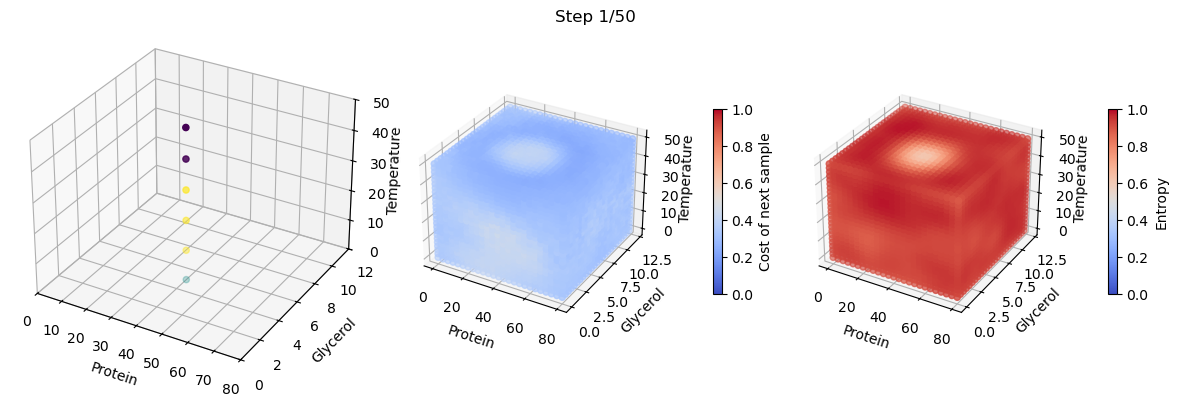

In [ ]:
ds_running = ds_init.copy() 

n_steps = 50
for step in range(n_steps):
    ds_result = p.calculate(ds_running, disable_progress_bar=True)

    next_sample = ds_result['next_sample'].to_pandas().to_dict(orient='records')[0]
    next_sample = ds_result['temper']
    ds_new = inst_client.simple_expose(next_sample)
    ds_running = xr.concat([ds_running, ds_new], dim='sample')
    fig, axs = plot_progress(ds_result)
    fig.suptitle(f"Step {step+1}/{n_steps}")
    plt.show()
    break

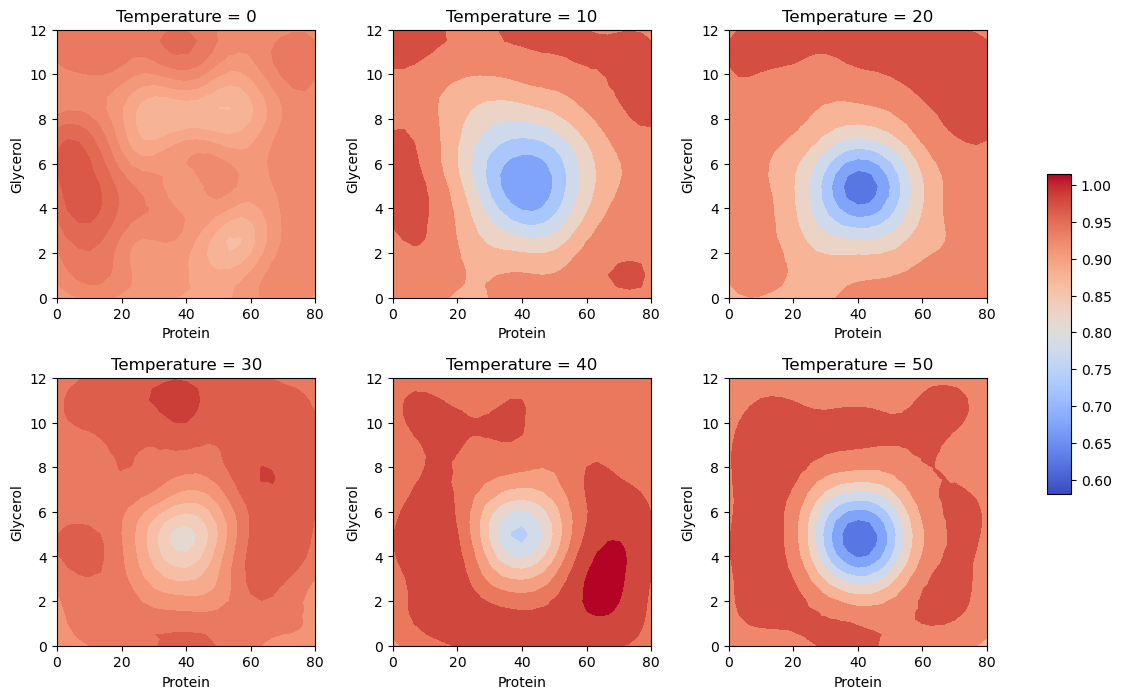

In [ ]:
plot_value_slices(ds_result, "phase_entropy")

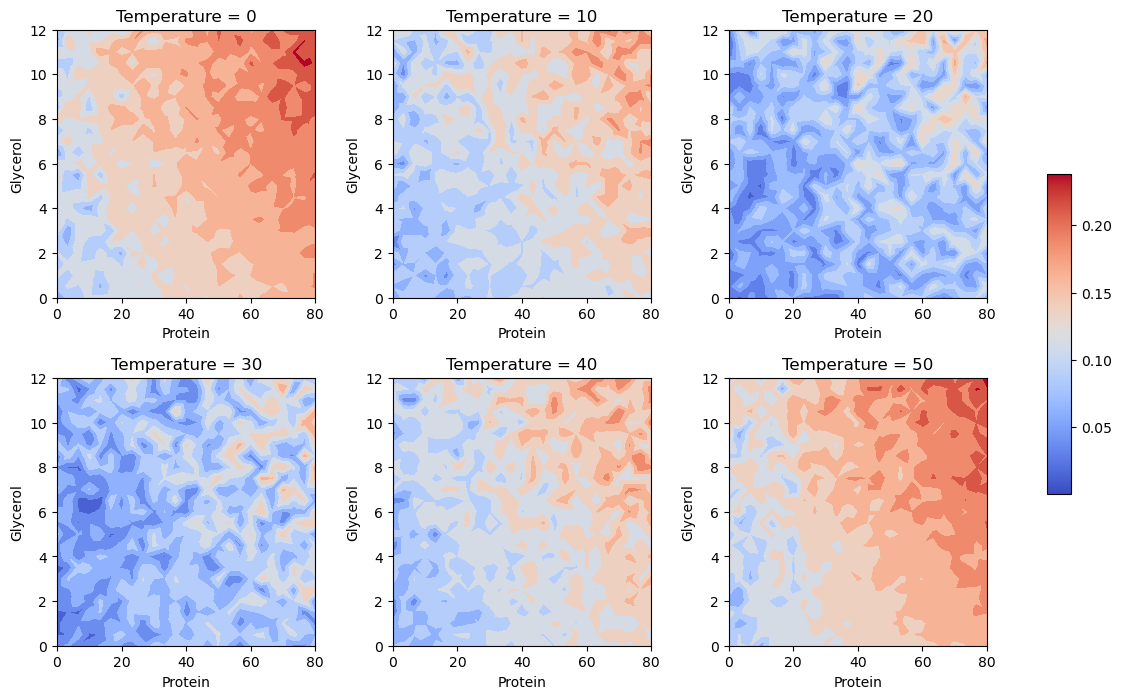

In [ ]:
plot_value_slices(ds_result, "hierarchy_cost")

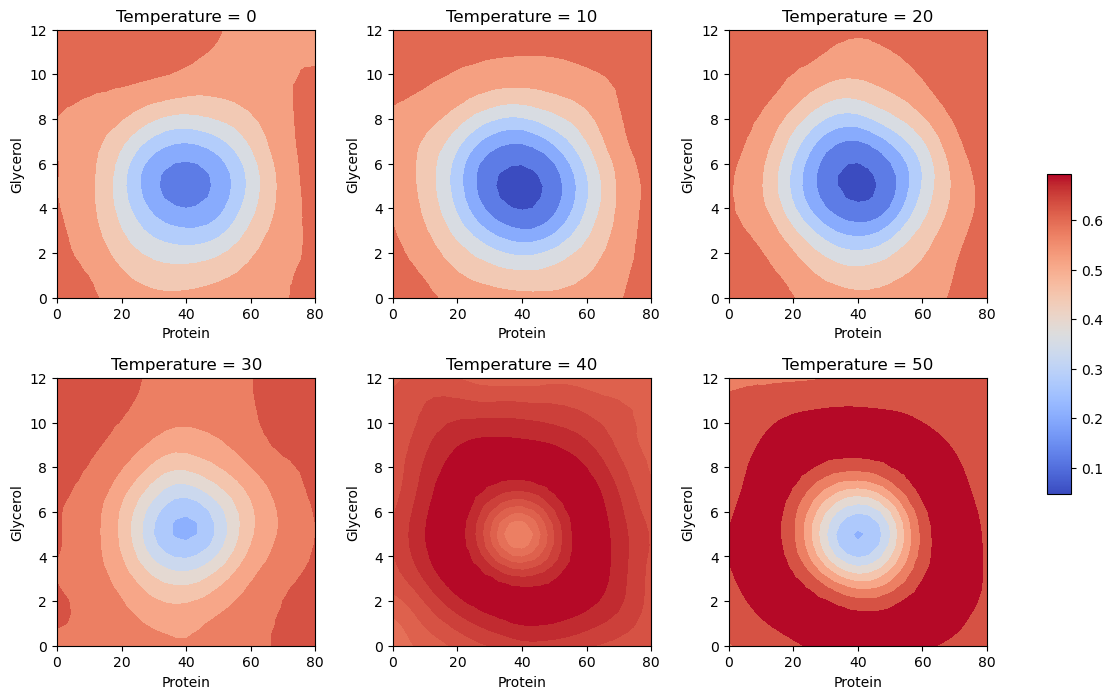

In [ ]:
plot_value_slices(ds_result, "feasibility_y_prob")

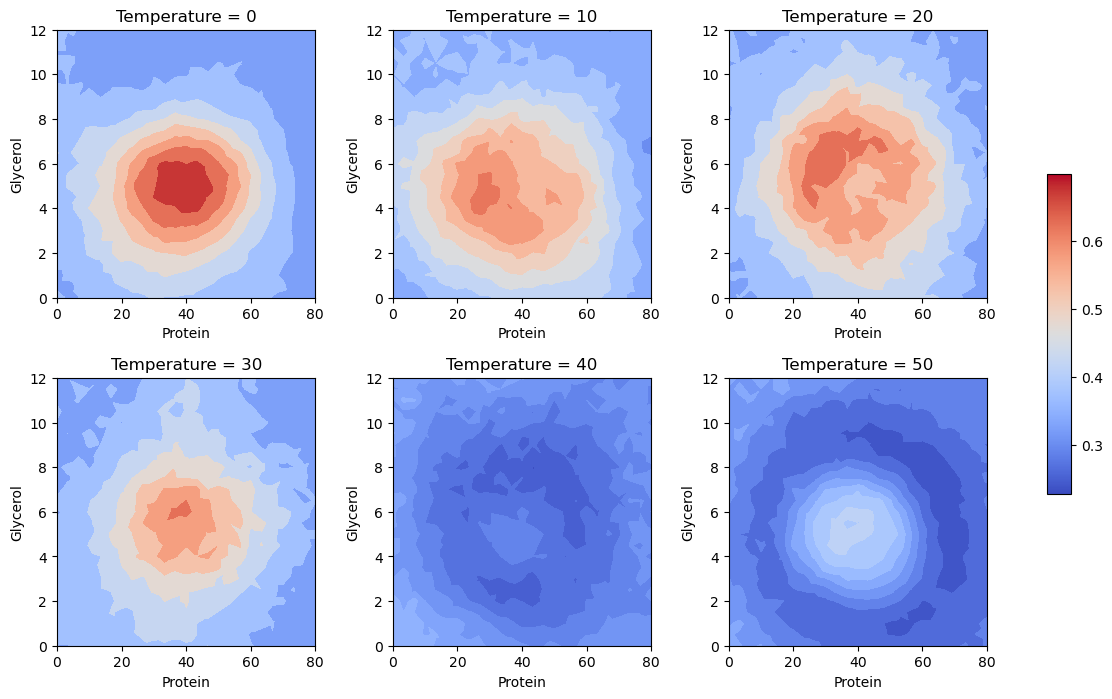

In [ ]:
plot_value_slices(ds_result, "acqv_cost")

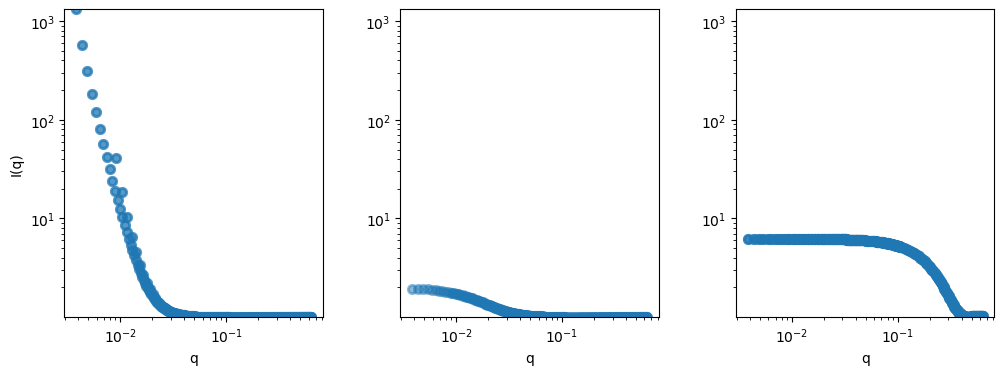

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
fig.subplots_adjust(wspace=0.3)
axs = axs.flatten()
q = ds_result.q.values 
Iq = ds_result.I.values
labels = ds_result.labels.values
for label in np.unique(labels):
    ax = axs[label]
    flags = labels == label
    Iq_current_phase = Iq[flags]
    for i in range(Iq_current_phase.shape[0]):
        ax.scatter(q, 
                  Iq_current_phase[i,:], 
                  color="tab:blue", 
                  lw=2.0, 
                  alpha=0.5
                )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("q")
    ax.set_ylim([Iq.min(), Iq.max()])
axs[0].set_ylabel("I(q)")
plt.show()